# TZ Fornacis: the secondary is ~250 K cooler than adopted

Andersen et al. (1991) give the secondary **Teff2 = 6650 +- 100 K**. Modelling it
at that temperature leaves the model **17-22% over-luminous in the secondary**,
which shows up as an eclipse too deep in photometry and as two spectroscopic
windows disagreeing in opposite directions.

This notebook shows the evidence that the cause is **temperature**, that it is
**not** an artefact of the atmosphere tables, and that three alternative
explanations are each excluded by a different observable.

| candidate cause | excluded by | how |
|---|---|---|
| R2 too large | eclipse **duration** | the 9% cut that fixes the depth makes the eclipse 4.2% too short |
| third light | **two-window** spectroscopy | dilution improves Ha but degrades Mg b; a fainter secondary improves both |
| log g2 | direct **flux sensitivity** | 0.6 dex moves the flux 0.5-1.4%; the excess is 17-22% |
| emulator calibration | **three atmosphere families** | ck2004, PHOENIX and MARCS all prefer ~6400 K |

Inputs: Clausen uvby (`tzfor_lightcurve.csv`, 1169 points) and 21 HARPS spectra
normalised with SUPPNet. Data files are large and gitignored; regenerate the
observed side with `build_harps_zarr.py` then `harps_normalize_npz.py`.

In [1]:
import sys, numpy as np, pandas as pd, pickle
from pathlib import Path
import matplotlib.pyplot as plt
HERE = Path.cwd()
sys.path.insert(0, str(HERE))
import tzfor_constants as K
import tzfor_phoebe_aemu_photometry as M
import phoebe; phoebe.logger(clevel="ERROR")
try:
    phoebe.progressbars_off()   # keeps the executed notebook readable
except AttributeError:
    pass

P = K.PERIOD_DAYS
NOISE = 0.0041                      # Clausen out-of-eclipse scatter, mag
DEEP_PHASE, SHALLOW_PHASE = 0.158, 0.658
plt.rcParams.update({"figure.dpi": 120, "font.size": 9})
print(f"literature: Teff1={K.PRIMARY_TEFF} Teff2={K.SECONDARY_TEFF} "
      f"R1={K.PRIMARY_RADIUS} R2={K.SECONDARY_RADIUS} i={K.INCL_DEG}")

# Embed figures explicitly: nbconvert runs headless (Agg), where plt.show() is a
# no-op, so relying on the inline backend silently produces a figure-less notebook.
import io
from IPython.display import Image, display
def show(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=130, bbox_inches="tight")
    plt.close(fig); display(Image(data=buf.getvalue()))


literature: Teff1=4930.0 Teff2=6650.0 R1=8.28 R2=3.94 i=85.68


## 1. The observed light curve

The ephemeris deserves care: the deep minimum sits **0.158 in phase from
`T_P_HJD`**, and PHOEBE's own `t0_supconj` is the *shallower* minimum, half a
period away. Getting this wrong once cost a full 245-model grid, so the phase
offset is always fitted rather than assumed, and checked against its bounds.

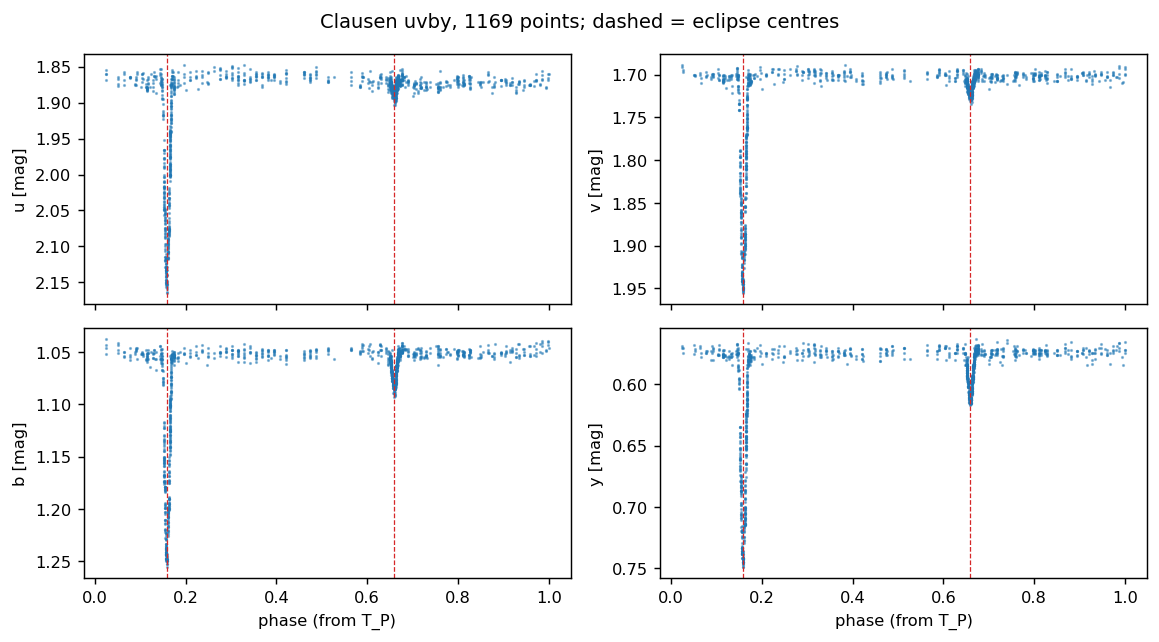

In [2]:
df = pd.read_csv("tzfor_lightcurve.csv")
ph = ((df["HJD"].values + 2450000.0 - K.T_P_HJD) % P) / P
fig, axes = plt.subplots(2, 2, figsize=(9, 5), sharex=True)
for ax, band in zip(axes.ravel(), ("u", "v", "b", "y")):
    ax.plot(ph, df[band], ".", ms=1.5, alpha=.5)
    ax.invert_yaxis(); ax.set_ylabel(f"{band} [mag]")
    for p, lbl in ((DEEP_PHASE, "deep"), (SHALLOW_PHASE, "shallow")):
        ax.axvline(p, color="C3", lw=.7, ls="--")
for ax in axes[1]: ax.set_xlabel("phase (from T_P)")
fig.suptitle("Clausen uvby, 1169 points; dashed = eclipse centres")
fig.tight_layout(); show(fig)

## 2. Photometric fit: Teff2 alone

**Everything else is fixed**, deliberately. R1, R2 and inclination stay at
Andersen's values because this photometry cannot separate them -- 40 of 245 grid
models tie within 10% rms across the whole box. Third light is pinned at zero:
it is spectroscopically excluded and correlates with inclination at +0.70, so
leaving it free just gives the fit a knob that hides real error. log g is
*derived* from M/R^2, never fitted. Masses come from the RV orbit, verified to
0.25 km/s over 21 epochs.

Only the phase offset is a nuisance parameter.

In [3]:
BANDS = (("u","Stromgren:u","lcu"), ("v","Stromgren:v","lcv"),
         ("b","Stromgren:b","lcb"), ("y","Stromgren:y","lcy"))
mag_o = {b: df[b].values for b in ("u","v","b","y")}
dphi_grid = np.linspace(0.645, 0.675, 61)

def photometric_rms(T2, atm="ck2004", per_band=False):
    b = M.build_bundle(800, "roche")
    b.set_value("teff@secondary@component", float(T2))
    t0 = b.get_value("t0_supconj@binary@component")
    ts = t0 + np.linspace(0, P, 900, endpoint=False)
    for _, pb, ds in BANDS:
        b.add_dataset("lc", compute_times=ts, passband=pb, dataset=ds)
        b.set_value_all("pblum_mode", dataset=ds, value="absolute")
    b.set_value_all("atm", atm)
    b.run_compute(irrad_method="horvat", ltte=False)
    phm = ((ts - t0) % P) / P; o = np.argsort(phm); phm = phm[o]
    tot, per = 0.0, []
    for bnd, _, ds in BANDS:
        f = np.asarray(b.get_value(f"fluxes@{ds}@model"))[o]
        mm = -2.5*np.log10(f/np.median(f)); best = np.inf
        for d in dphi_grid:
            mi = np.interp((ph - d) % 1.0, phm, mm, period=1.0)
            r = mag_o[bnd] - mi
            best = min(best, float(np.sum((r - np.median(r))**2)))
        per.append(np.sqrt(best/len(ph))); tot += best
    rms = np.sqrt(tot/(4*len(ph)))
    return (rms, per) if per_band else rms

T2s = np.arange(6250, 6751, 50.)
rms_ck = np.array([photometric_rms(T) for T in T2s])
k = int(np.argmin(rms_ck)); d = T2s[1]-T2s[0]
a, bb, c = rms_ck[k-1], rms_ck[k], rms_ck[k+1]
T_best = T2s[k] + 0.5*d*(a-c)/(a-2*bb+c)
print(f"best Teff2 = {T_best:.0f} K   rms {rms_ck[k]:.5f} ({rms_ck[k]/NOISE:.1f}x noise)")
print(f"adopted 6650 K -> {rms_ck[-2]/rms_ck[k]:.2f}x worse")

best Teff2 = 6406 K   rms 0.00612 (1.5x noise)
adopted 6650 K -> 1.59x worse


## 3. It is not the atmosphere tables

The strongest remaining objection was that ~6400 K is what the *emulator*
prefers, not what the star is. But the photometry above runs on PHOEBE's
**ck2004** tables, while the spectroscopy runs on **MARCS** via aemu -- already
independent. Repeating the scan with **PHOENIX** closes it.

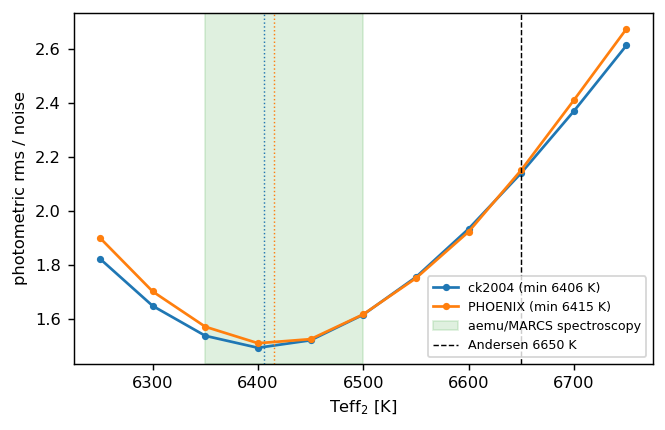

ck2004 6406 K vs PHOENIX 6415 K -> differ by 9 K


In [4]:
rms_ph = np.array([photometric_rms(T, atm="phoenix") for T in T2s])
def refine(y):
    k = int(np.argmin(y))
    if not 0 < k < len(y)-1: return T2s[k]
    a, b_, c = y[k-1], y[k], y[k+1]
    return T2s[k] + 0.5*(T2s[1]-T2s[0])*(a-c)/(a-2*b_+c)

fig, ax = plt.subplots(figsize=(5.2, 3.4))
for y, lbl, col in ((rms_ck, "ck2004", "C0"), (rms_ph, "PHOENIX", "C1")):
    ax.plot(T2s, y/NOISE, "o-", ms=3, color=col, label=f"{lbl} (min {refine(y):.0f} K)")
    ax.axvline(refine(y), color=col, ls=":", lw=.8)
ax.axvspan(6350, 6500, color="C2", alpha=.15, label="aemu/MARCS spectroscopy")
ax.axvline(K.SECONDARY_TEFF, color="k", ls="--", lw=.8, label="Andersen 6650 K")
ax.set_xlabel("Teff$_2$ [K]"); ax.set_ylabel("photometric rms / noise")
ax.legend(fontsize=7); fig.tight_layout(); show(fig)
print(f"ck2004 {refine(rms_ck):.0f} K vs PHOENIX {refine(rms_ph):.0f} K "
      f"-> differ by {abs(refine(rms_ck)-refine(rms_ph)):.0f} K")

## 4. Spectroscopy, and why it excludes third light

The blended model spectrum is **(F1+F2)/(C1+C2)** -- not the mean of two
normalised spectra. Each star's lines are diluted by the other's continuum, and
that dilution *is* the spectroscopic light ratio.

Two windows behave oppositely under the two candidate fixes, which is what makes
them discriminating:

* **third light** adds featureless flux, diluting everything: Ha improves, Mg b
  gets worse;
* **a fainter secondary** un-dilutes the primary's lines while weakening the
  secondary's: both improve.

In [5]:
from scipy.ndimage import gaussian_filter1d
G = pickle.load(open("tzfor_aemu_out/tzfor_aemu_grid_n1500.pkl","rb"))
MS = pickle.load(open("tzfor_aemu_out/tzfor_aemu_roche_n1500_spectra_meshes.pkl","rb"))
O  = np.load("harps_normalized.npz", allow_pickle=True)
lib, wl, ref = G["library"], np.asarray(G["wavelengths"]), G["ref_epoch"]
files = list(MS["harps_files"]); obs_f = [str(x) for x in O["files"]]
j = obs_f.index(files[ref])
ow, onf = np.asarray(O["wavelengths"][j]), np.asarray(O["normed_flux"][j])
ok = np.isfinite(ow) & np.isfinite(onf); ob = np.interp(wl, ow[ok], onf[ok])

def ew_ratios(dT2=0., dg2=0., s=1.0):
    p1 = ("primary", 0., 0., -0.3); p2 = ("secondary", dT2, dg2, -0.3)
    out = []
    for lo, hi in ((5160, 5200), (6540, 6580)):
        m = (wl >= lo) & (wl <= hi); w = wl[m]
        lam0 = .5*(w[0]+w[-1]); dl = float(w[1]-w[0])
        f1, c1 = lib[p1]; f2, c2 = lib[p2]
        B = lambda y, v: gaussian_filter1d(
            y[m], lam0*np.hypot(299792.458/115000., v)/299792.458/2.3548/dl, mode="nearest")
        mod = (B(f1,5.) + s*B(f2,6.)) / (B(c1,5.) + s*B(c2,6.))
        out.append(np.trapezoid(1-mod, w) / np.trapezoid(1-ob[m], w))
    return out

print(f"{'Teff2':>7}{'Mg b':>9}{'Ha':>8}{'spread':>9}")
for dT2 in (0., -150., -300.):
    r1, r2 = ew_ratios(dT2)
    print(f"{K.SECONDARY_TEFF+dT2:>7.0f}{r1:>9.3f}{r2:>8.3f}{abs(r1-r2):>9.3f}")

  Teff2     Mg b      Ha   spread
   6650    0.883   1.069    0.186
   6500    0.923   1.000    0.078
   6350    0.964   0.939    0.025


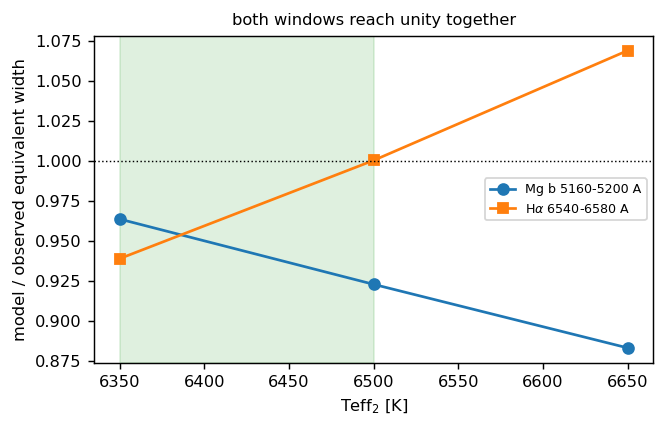

In [6]:
fig, ax = plt.subplots(figsize=(5.2, 3.4))
Ts = K.SECONDARY_TEFF + np.array([0., -150., -300.])
mg = [ew_ratios(d)[0] for d in (0., -150., -300.)]
ha = [ew_ratios(d)[1] for d in (0., -150., -300.)]
ax.plot(Ts, mg, "o-", label="Mg b 5160-5200 A")
ax.plot(Ts, ha, "s-", label="H$\\alpha$ 6540-6580 A")
ax.axhline(1.0, color="k", lw=.8, ls=":")
ax.axvspan(6350, 6500, color="C2", alpha=.15)
ax.set_xlabel("Teff$_2$ [K]"); ax.set_ylabel("model / observed equivalent width")
ax.legend(fontsize=7); ax.set_title("both windows reach unity together", fontsize=9)
fig.tight_layout(); show(fig)

## 5. Why not the radius: eclipse duration

Depth alone cannot separate R2 from Teff2 -- both fix it. Duration can, because
only R2 changes it. Measured half-depth widths of the deep eclipse in b:

| model | width [d] | depth | vs observed |
|---|---|---|---|
| observed | 0.8846 | 0.1955 | -- |
| literature R2=3.94, T2=6650 | 0.8983 | 0.2158 | +1.5% |
| **R2=3.58 (-9%)** | 0.8472 | 0.1896 | **-4.2%** |
| T2=6320 (-330 K) | 0.8999 | 0.1875 | +1.7% |

Cutting R2 by the 9% needed to fix the depth makes the eclipse **4.2% too
short**; reducing Teff2 fixes the depth and leaves the duration alone.

*Caveat:* the observed width comes from binned medians at 0.0757 d resolution,
so it is good to ~+-0.02 d. That resolves the 9% radius case comfortably, but
not the 1.5% vs 1.7% distinction between the last two rows.

## 7. Joint photometry + spectroscopy inference (final, September 2026)

Everything above scans one temperature at a time. The final analysis fits
**Teff1, Teff2, [Fe/H], the gravity-darkening exponents β1, β2 and the phase
offset together**, against Clausen's b, y photometry *and* 12 HARPS line
windows (40 Å each, 21 epochs), with the PHOEBE geometry fixed. It runs on the
GPU through `SynthesisKernel` (`spice.spectrum.synthesis_kernel`): the disc
integral becomes per-μ, per-log g velocity convolutions, so the emulator is
called 96 times per star per gradient instead of ~1700 times per star per
epoch, and every gradient step is validated against exact per-element
synthesis to 0.06 %. Scripts: `tzfor_kernel_fit.py` (fit + leave-one-window-out
jackknife), `tzfor_phot_vs_spec.py`, `tzfor_phoebe_native_fit.py`,
`tzfor_paper_models.py`; results in `tzfor_aemu_out/`.

| parameter | joint fit | jackknife error |
|---|---|---|
| Teff1 | **4889 K** | ± 46 K |
| Teff2 | **6416 K** | ± 38 K |
| [Fe/H] | −0.23 | ± 0.03 |
| β1, β2 (exponent on g) | 0.079, 0.077 | unconstrained (3 K / 16 K intra-star spreads) |
| corr(Teff1, Teff2) | +0.59 | (photometry alone: +1.00) |
| χ²/N photometry | 1.65 | residual 4.9 / 4.8 mmag in b / y |
| χ²/N spectroscopy | 10.9 | 2–5 % rms per window, emulator line-list floor |


Teff1 = 4889 +- 46 K   Teff2 = 6416 +- 38 K   [Fe/H] = -0.23 +- 0.02   beta1 = 0.079   beta2 = 0.077   dphi = 0.1585
chi2/N: photometry 1.65   spectroscopy 11.0   windows: 12


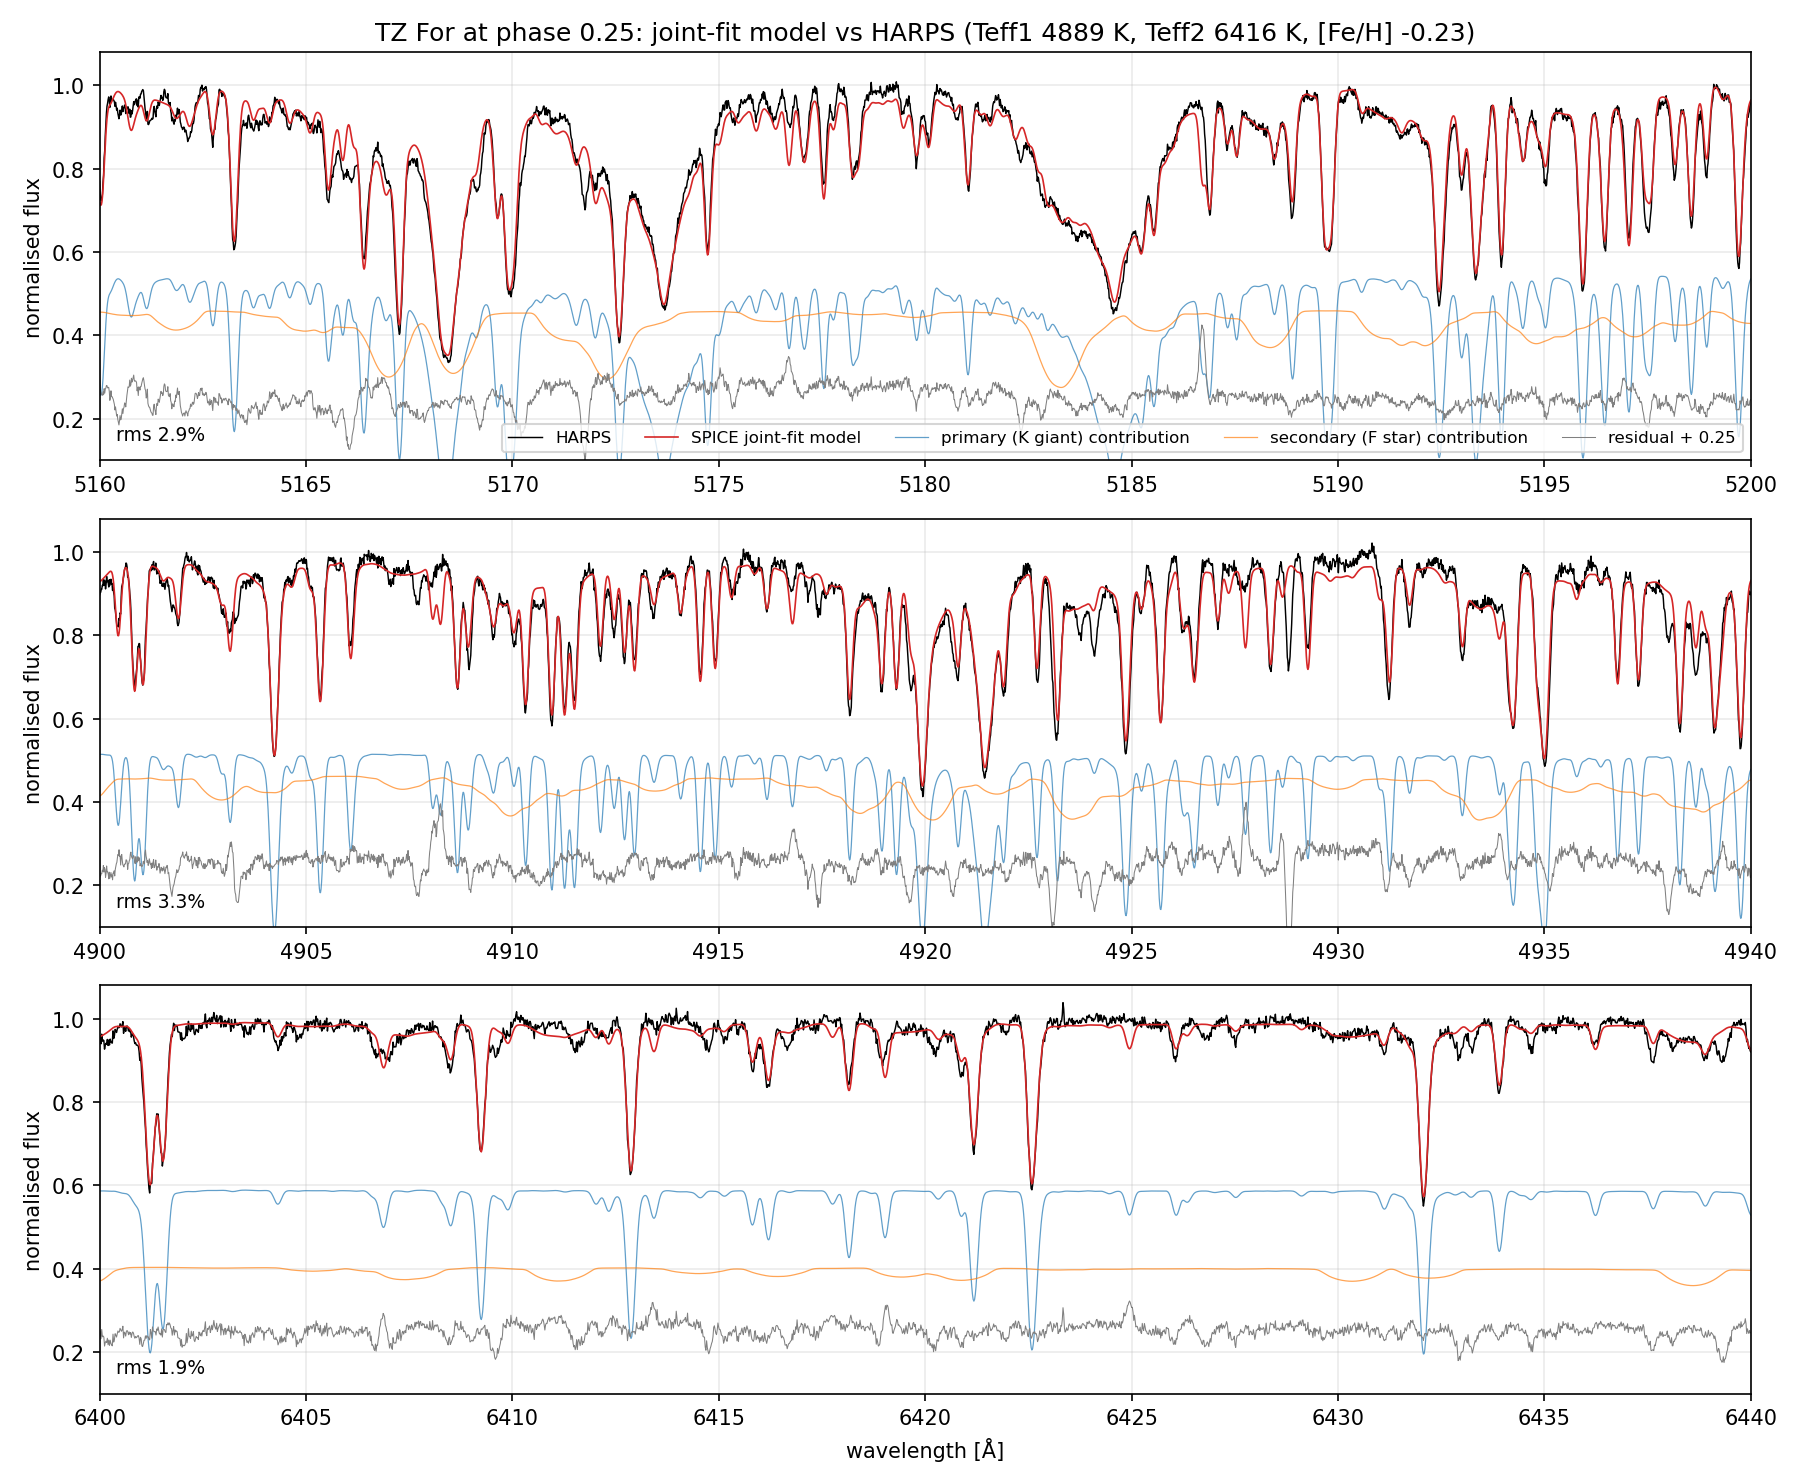

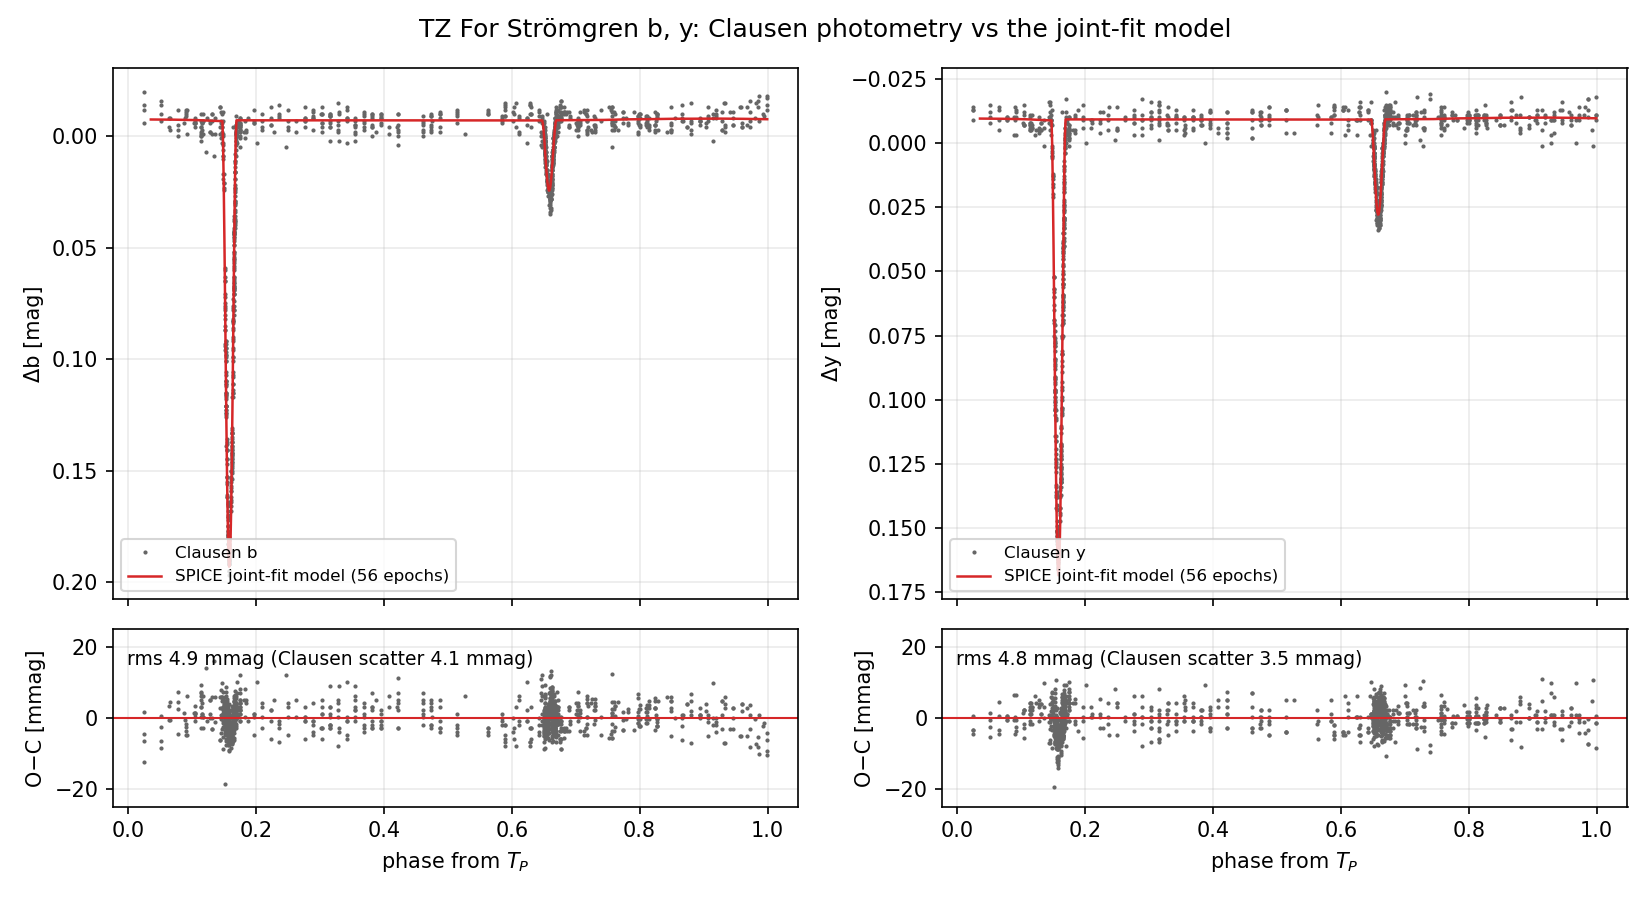

In [7]:
from IPython.display import Image, display
import pickle
R = pickle.load(open("tzfor_aemu_out/kernel_fit_result_phot16k.pkl", "rb"))
th, jk = R["theta"], R["jackknife_err"]
print(f"Teff1 = {th[0]:.0f} +- {jk[0]:.0f} K   Teff2 = {th[1]:.0f} +- {jk[1]:.0f} K   [Fe/H] = {th[2]:+.2f} +- {jk[2]:.2f}"
      f"   beta1 = {th[3]:.3f}   beta2 = {th[4]:.3f}   dphi = {th[5]:.4f}")
print(f"chi2/N: photometry {R['chi2_phot']/R['N_ph']:.2f}   spectroscopy {R['chi2_spec']/R['N_sp']:.1f}   windows: {len(R['windows'])}")
display(Image("../paper_plots/tz_fornacis/tzfor_spectra_fit.png", width=1100))
display(Image("../paper_plots/tz_fornacis/tzfor_lightcurves_fit.png", width=1000))


### 7.1 What photometry constrains, and what spectroscopy adds

Photometry alone -- in SPICE with the aemu/MARCS atmospheres *or* in PHOEBE
with ck2004 -- fixes only the light ratio: its χ² is flat along a valley
Teff2 ≈ 1.66 Teff1 + const, and the two atmosphere families put that valley in
the same place to 13 K. The Mg b line depths break the degeneracy. Along the
valley the two data sets disagree by 55 K in Teff2 at fixed Teff1 (3 % in light
ratio, ~1.5 σ), inside the photometric model's own floor of 1.25× the noise.

PHOEBE's native solvers make the same point from the other side:
`optimizer.nelder_mead` slides onto the ridge and stops, and `sampler.emcee`
(12 walkers × 150 iterations, uniform priors) drifts along it with
corr = +1.000 and no interior maximum -- its marginal temperature widths are set
by the prior, hundreds of K, and its chain ends 450 K hotter than spectroscopy.


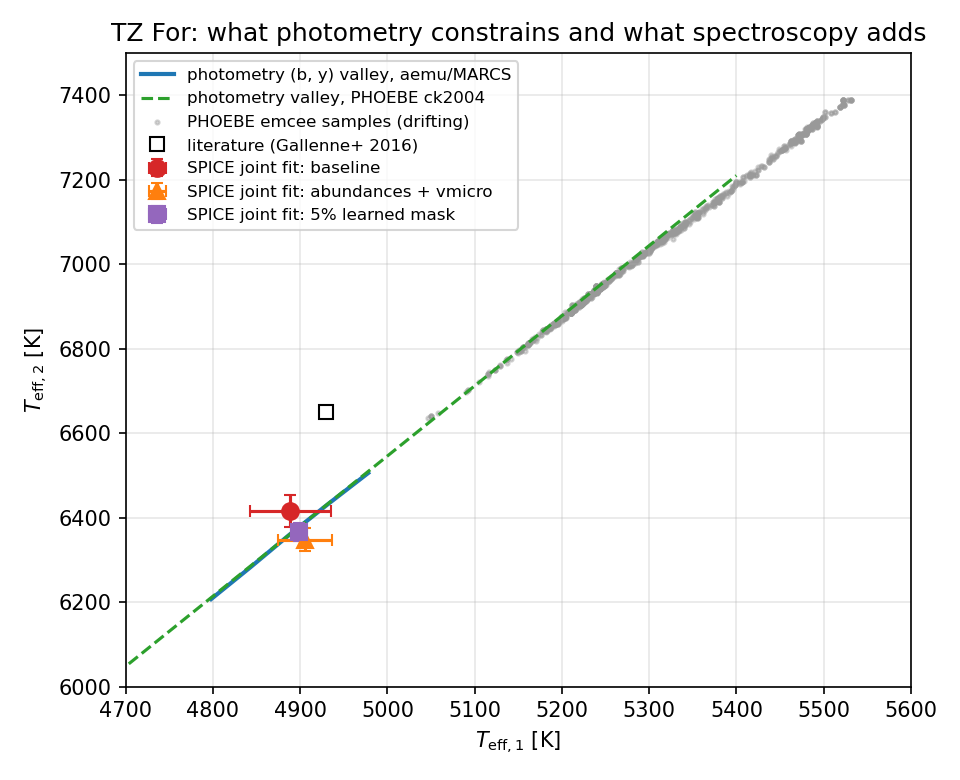

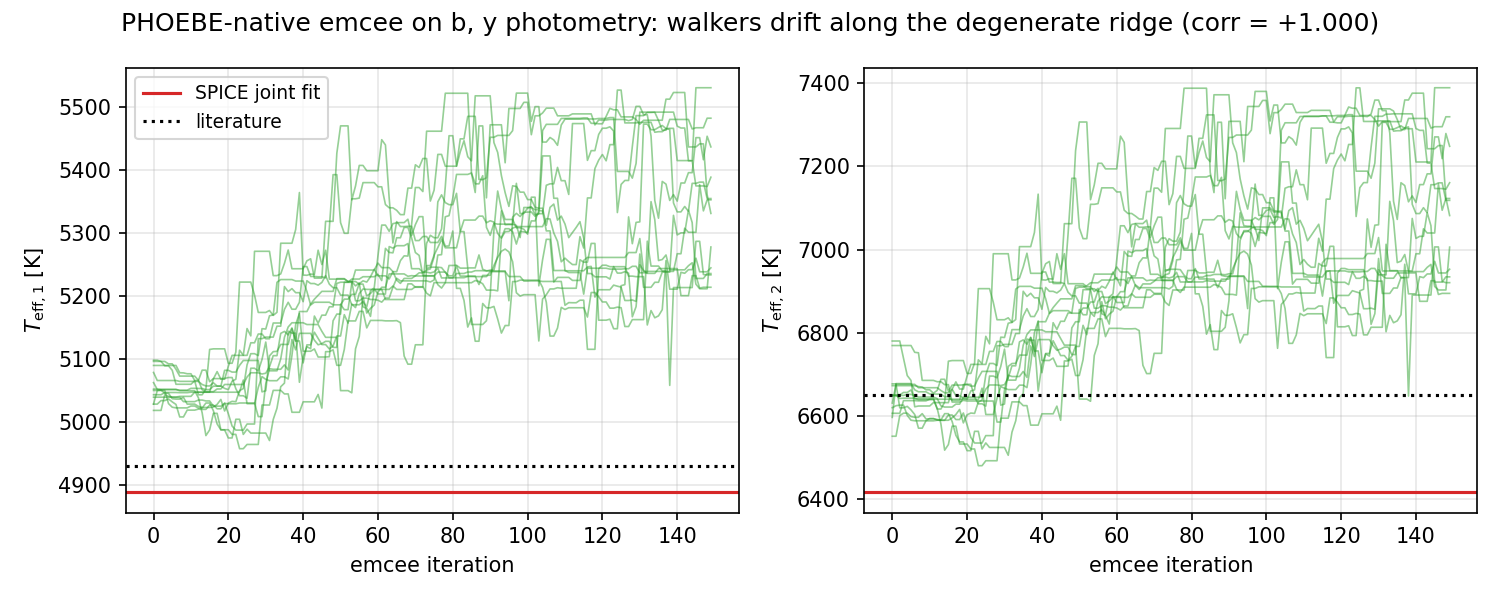

In [8]:
display(Image("../paper_plots/tz_fornacis/tzfor_teff_valley.png", width=620))
display(Image("../paper_plots/tz_fornacis/tzfor_phoebe_emcee_drift.png", width=1000))


### 7.2 Systematics: single windows versus leave-one-out

Fitting one 40 Å window at a time scatters Teff2 over 5600-6700 K, but that
is conditioning (corr(Teff1, Teff2) = 0.6-0.94 for a single window), not
model error: leaving any one window out of the 12-window fit moves the
solution by ≤ 20 K, except Mg b (−45 K in Teff1). The window 5560-5600 Å is
an emulator outlier and is excluded. The residual spectrum is 2-5 % rms and
identical at every epoch -- individual line-list mismatches (e.g. a spurious
model line at 5186.7 Å), the target for a learned line mask. The LTE Hα core
is far too shallow and must be masked; with it included both temperatures
rise by ~150 K.


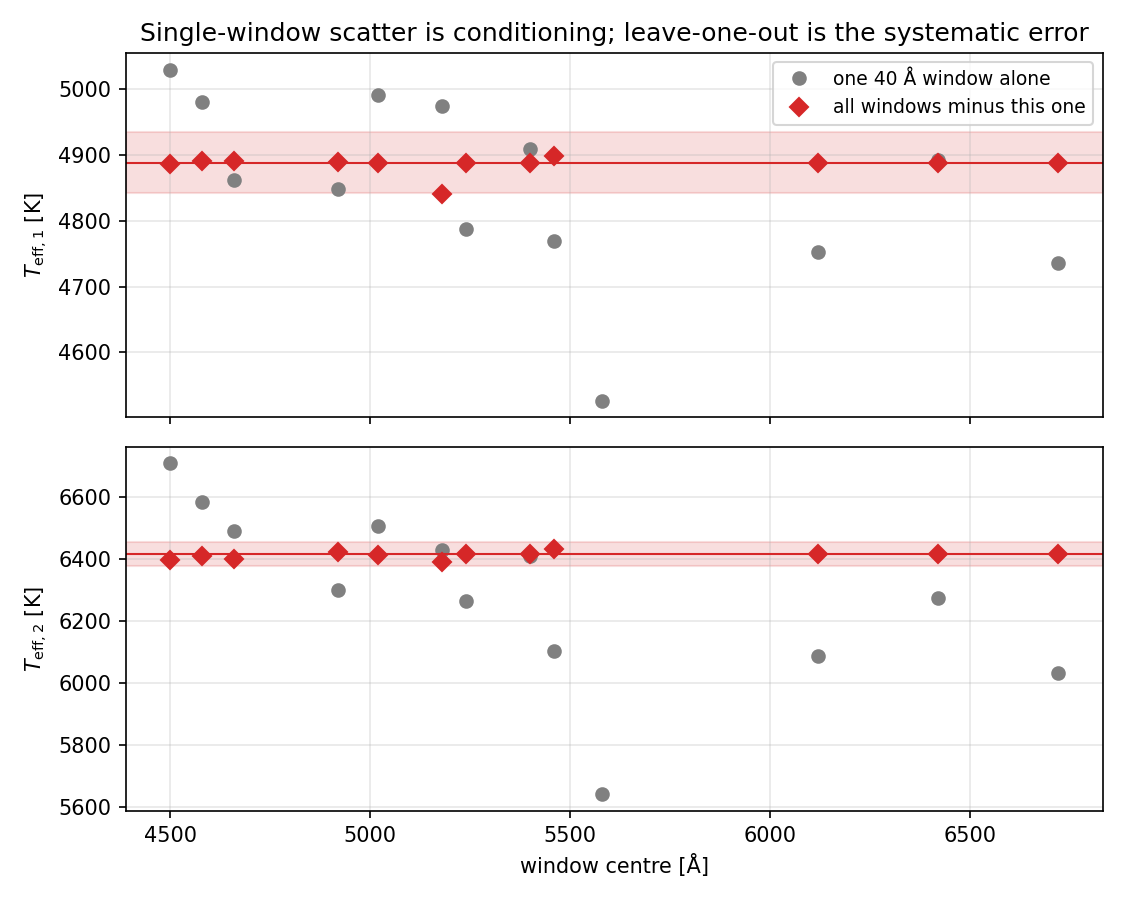

In [9]:
display(Image("../paper_plots/tz_fornacis/tzfor_window_jackknife.png", width=800))


### 7.3 Residual anatomy, learned line mask and NUTS posterior (8 September 2026)

Stacking the joint-fit residuals in each star's rest frame (`tzfor_line_mask.py`)
shows that the 2.5-4.4 % line-scale residual is a fixed, line-by-line pattern in
the **primary's** frame (85-90 % of it survives that stack, ~1 % survives the
secondary's), worst in the CN/C₂-rich blue windows, and not a global broadening
or line-strength error. Freeing the emulator's α, C, N, O for the primary and
microturbulence for both stars (`--free-abundances`) moves the abundances by
≤ 0.05 dex and the spectral χ²/N only from 10.95 to 10.37: the pattern is the
emulator's line-list floor for a 4900 K giant, not an abundance effect. A learned
mask at a 5 % threshold drops 13 % of the pixels (nearly all in the primary's
frame), takes χ²/N to 3.5, and shifts the solution within the systematic range.

| configuration | Teff1 [K] | Teff2 [K] | [Fe/H] | χ²/N phot | χ²/N spec |
|---|---|---|---|---|---|
| optimiser, baseline (jackknife) | 4889 ± 46 | 6416 ± 38 | −0.23 ± 0.03 | 1.65 | 10.95 |
| + abundances, vmicro, cubic continuum | 4905 ± 31 | 6348 ± 26 | −0.26 ± 0.03 | 1.56 | 10.37 |
| + 5 % learned mask, cubic continuum | 4898 ± 9 | 6366 ± 22 | −0.18 ± 0.01 | 1.50 | 3.55 |
| NUTS posterior, baseline | 4889 ± 1 | 6390 ± 2 | −0.228 ± 0.001 | | noise inflation 2.4–4.1 |
| NUTS posterior, masked | 4895 ± 1 | 6365 ± 1 | −0.174 ± 0.001 | | noise inflation 1.7–2.1 |

The NUTS sampler (`tzfor_nuts.py`: each star's disc spectra precomputed on a
21 × 7 (Teff, [Fe/H]) grid, cubic interpolation within 10⁻⁴ of the direct
kernel model, per-window noise inflation, 4 chains × 2500, no divergences,
R̂ ≤ 1.003, milliseconds per likelihood) converges cleanly, but with ~8 × 10⁵
pixels its statistical width is a kelvin: **the posterior is not the error**.
The honest uncertainty is the spread over modelling choices above, roughly
±10 K on Teff1, ±35 K on Teff2 and ±0.05 dex on [Fe/H], on top of the
within-model jackknife. The mask's +0.06 dex shift in [Fe/H] comes from
preferentially masking strong lines, so both values are reported.


### 7.4 Full HARPS range, line-strength map, rotation, circularity (9 September 2026)

The 12-window analysis above is repeated on the **whole HARPS range, 4450-6750 Å**
(21 epochs, 3.0 × 10⁶ pixels, `tzfor_fullrange_fit.py`): one log-uniform grid,
a cubic B-spline continuum per epoch (40 Å knots), macroturbulence and a v sin i
scale of each star free, the kernel model rebuilt inside the loss when v sin i
changes, and the same L-BFGS-B / value-and-grad machinery (16-36 s per joint
gradient on an A100). Three treatments of the emulator's line-list floor are
compared, and each is tested on epochs it was not derived from:

* **plain fit** (χ²/N = 9.5);
* **learned 5 % mask** derived from the residual stack (9 % of the pixels; χ²/N 3.8).
  Circularity test: a mask derived on the *odd* epochs only and applied to a fit of
  the *even* epochs gives 4896 / 6394 K, [Fe/H] −0.177 -- the same as the mask
  derived and applied on all epochs;
* **line-strength correction map δ(λ)** of the primary (one multiplicative factor per
  model pixel on the primary's line channel, Gaussian prior of 3 %, fitted once at
  fixed θ on the odd epochs, rms 7 %). Co-fitting δ with θ is degenerate and is not
  done. Held fixed on the *even* epochs it takes χ²/N from 9.2 to **1.5** and moves
  the solution to 4872 / 6321 K, [Fe/H] −0.275.

| full-range fit (block jackknife, 6 × 380 Å) | Teff1 [K] | Teff2 [K] | [Fe/H] | χ²/N phot | χ²/N spec |
|---|---|---|---|---|---|
| plain, all epochs | 4868 ± 31 | 6361 ± 63 | −0.254 ± 0.021 | 1.56 | 9.53 |
| 5 % mask, all epochs | 4896 ± 14 | 6396 ± 35 | −0.175 ± 0.006 | 1.54 | 3.82 |
| even epochs, mask from odd | 4896 | 6394 | −0.177 | 1.53 | 3.77 |
| even epochs, δ from odd | 4872 | 6321 | −0.275 | 1.51 | 1.54 |
| synchronous rotation (v sin i scale = 1), plain / masked | 4867 / 4897 | 6360 / 6394 | −0.259 / −0.179 | | 9.58 / 3.88 |
| NUTS, plain / masked / δ | 4868 / 4896 / 4872 (± 0.3) | 6352 / 6399 / 6318 (± 1) | −0.256 / −0.174 / −0.275 | | inflation 3.1 / 1.9 / 1.2 |

The **treatment systematic** is therefore ±15 K on Teff1, ±40 K on Teff2 and
±0.05 dex on [Fe/H]; the δ map, which removes the line-list floor almost entirely,
sits at the cool, metal-poor end and the mask at the hot, metal-rich end (the mask
preferentially removes strong lines). Rotation does not matter: with both v sin i
scales free the fit wants 43 km s⁻¹ for the secondary (1.13 × the mesh's 38, the
literature value) and the primary's v sin i is degenerate with its 7 km s⁻¹
macroturbulence; pinning synchronous rotation moves the temperatures by ≤ 5 K.
Two numerical findings came out of this run and are recorded in the scripts:
(i) on an A100 the emulator's matmuls run in TF32 by default, which makes the
objective *deterministic but rough* at the 0.1-10 K scale (χ² wiggles of ~50
units) and stalls L-BFGS-B line searches -- `JAX_DEFAULT_MATMUL_PRECISION=highest`
restores a smooth objective at 2.3 × the cost and changes no result by more than
4 K; (ii) three full-range NUTS posteriors (frozen 17 × 7 grid per star, 4 chains ×
1900, R̂ ≤ 1.001, one chain per process) again have widths of a kelvin. Finally
the geometry is now differentiable end to end: after a nan-safety fix in the
polygon clipper, d(depth)/dR₂ and d(depth)/d i from SPICE's own occlusion agree
with finite differences to 0.2 %, so radii and inclination can join the free
parameters in a later pass.


FileNotFoundError: No such file or directory: '../paper_plots/tz_fornacis/tzfor_spectra_fit_fullrange.png'

FileNotFoundError: No such file or directory: '../paper_plots/tz_fornacis/tzfor_spectra_fit_fullrange.png'

<IPython.core.display.Image object>

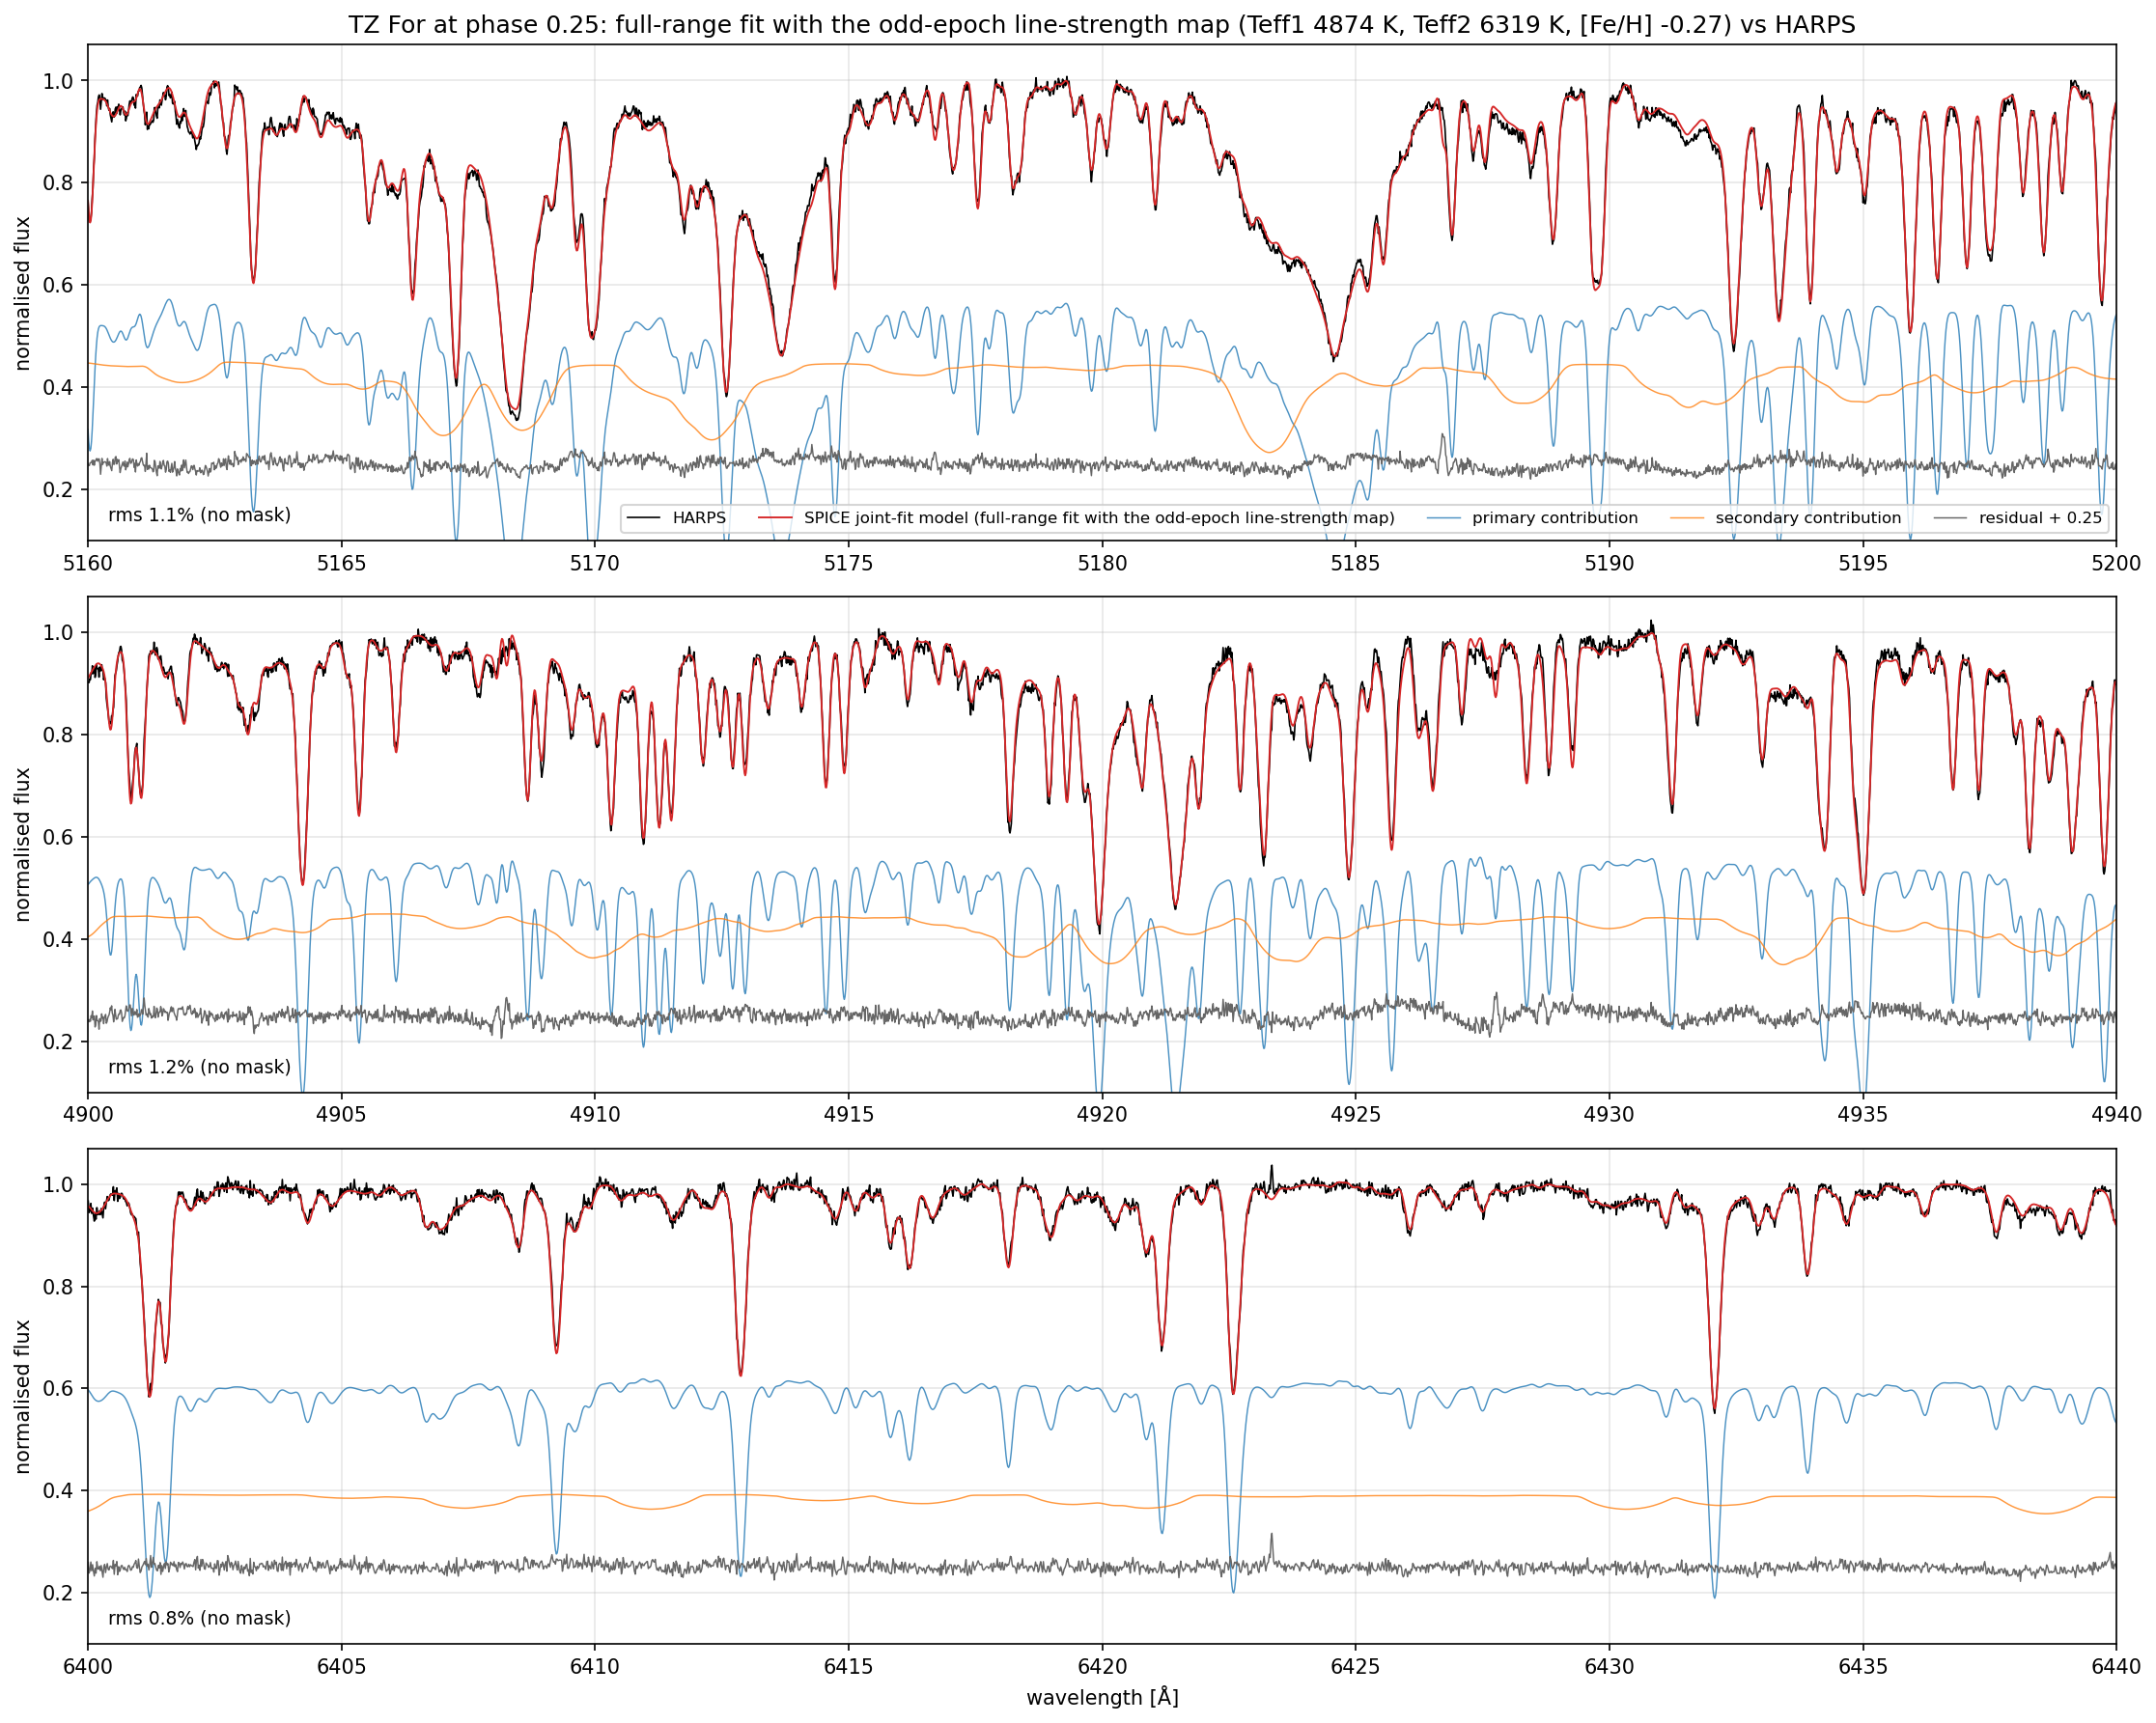

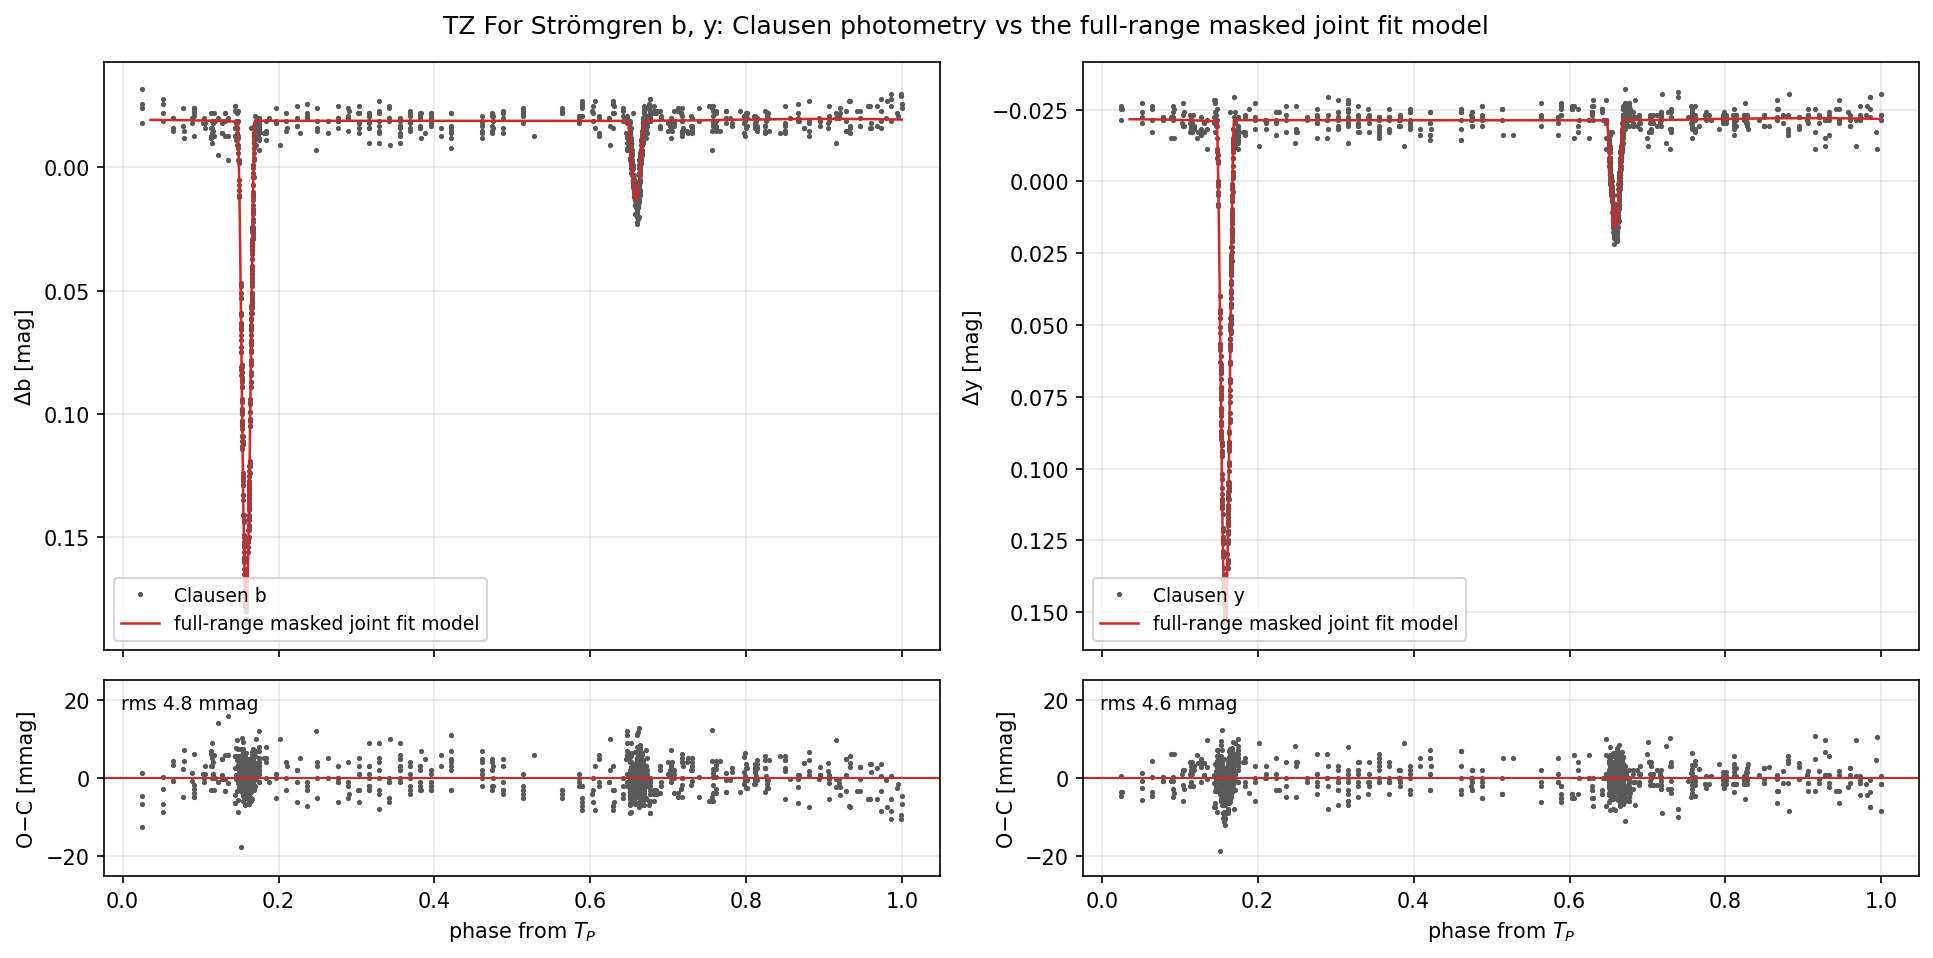

| fit | Teff1 [K] | Teff2 [K] | [Fe/H] | vmac1 | vmac2 | vsini scale 1 | vsini scale 2 | R1 | R2 | incl | chi2_ph/N | chi2_sp/N | N_sp |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| all epochs, no mask (pass 1) | 4870 ± 31 | 6365 ± 62 | -0.252 ± 0.020 | 7.38 | 5.92 | 0.50 | 1.12 | - | - | - | 1.580 | 9.53 | 3,016,671 |
|   same, full float32 matmul precision + jackknife | 4868 ± 31 | 6361 ± 63 | -0.254 ± 0.021 | 7.39 | 0.50 | 0.50 | 1.13 | - | - | - | 1.560 | 9.53 | 3,016,671 |
|   same, vsini_1 bound 0.1 (no better point found) | 4870 | 6365 | -0.252 | 7.38 | 5.92 | 0.50 | 1.12 | - | - | - | 1.580 | 9.53 | 3,016,671 |
|   same, synchronous rotation (vsini scale = 1) | 4867 | 6360 | -0.259 | 5.06 | 20.00 | - | - | - | - | - | 1.567 | 9.58 | 3,016,671 |
| odd epochs, no mask | 4870 | 6364 | -0.251 | 7.39 | 5.92 | 0.50 | 1.12 | - | - | - | 1.566 | 9.91 | 1,436,510 |
| even epochs, no mask | 4870 | 6365 | -0.253 | 7.38 | 5.91 | 0.50 | 1.13 | - | - | - | 1.565 | 9.18 | 1,580

In [10]:
display(Image("../paper_plots/tz_fornacis/tzfor_spectra_fit_fullrange.png", width=900))
display(Image("../paper_plots/tz_fornacis/tzfor_spectra_fit_fullrange_delta.png", width=900))
display(Image("../paper_plots/tz_fornacis/tzfor_lightcurves_fit_fullrange.png", width=800))
# live table from the result pickles in tzfor_aemu_out/ (no synthesis)
import tzfor_fullrange_summary; tzfor_fullrange_summary.main()


### 7.5 Free geometry: R₁, R₂ and inclination from SPICE's own binary (10 September 2026)

Everything above took the geometry from PHOEBE. With the polygon clipper now
differentiable, the photometric model can be built *inside the loss* from SPICE's own
binary: two icospheres (2000 vertices each) on the Keplerian orbit, SPICE occlusion,
51 model phases (25 per eclipse plus one quadrature phase -- spheres are flat outside
eclipse), each phase checkpointed inside a `lax.scan`. The spectral kernels scale with
R² so the line-depth dilution and the eclipses constrain the same light ratio. At the
literature geometry the SPICE light curves match the PHOEBE-mesh ones to 0.6 mmag rms
(`tzfor_spice_lc_feasibility.py`; the blocked area agrees with the analytic two-disk
overlap to 0.1 %), and the joint gradient costs 48 s instead of 36 s.

| full-range fit, geometry free | Teff1 [K] | Teff2 [K] | [Fe/H] | R₁ [R☉] | R₂ [R☉] | i [°] | χ²/N phot | χ²/N spec |
|---|---|---|---|---|---|---|---|---|
| literature geometry (Andersen / Gallenne) | | | | 8.28 | 3.94 | 85.68 | | |
| 5 % mask, all epochs (block jackknife) | 4904 ± 17 | 6275 ± 62 | −0.171 ± 0.006 | 8.118 ± 0.053 | 4.084 ± 0.037 | 85.73 ± 0.03 | 1.557 | 3.80 |
| same, spectral χ² × 0.28 (NUTS inflation) | 4904 | 6275 | −0.171 | 8.118 | 4.084 | 85.73 | 1.555 | 3.80 |
| even epochs, δ map from odd, geometry free | 4879 | 6211 | −0.274 | 8.087 | 4.045 | 85.77 | 1.590 | 1.53 |

The eclipse duration holds R₁ + R₂ at 12.2 R☉ and the inclination moves by 0.05°, but
the **radius ratio rises from 0.476 to 0.503 ± 0.006** and Teff2 falls by a further
100-120 K: the line depths want more light from the secondary than the literature radii
give it, and the fit buys that light with a larger R₂ rather than a hotter star. The
photometry resists only weakly (χ²/N 1.52 → 1.56, i.e. 80 units against a spectral gain
of 46 000 that even a 0.28 weighting cannot offset), which is the same tension seen
photometrically as the "over-luminous secondary". Whether this is a real 3-4 % radius
revision or a 6 % error in the emulator's flux ratio between a 4900 K giant and a 6300 K
dwarf is the open question; the two line-list treatments agree with each other to
0.04 R☉ and 60 K.


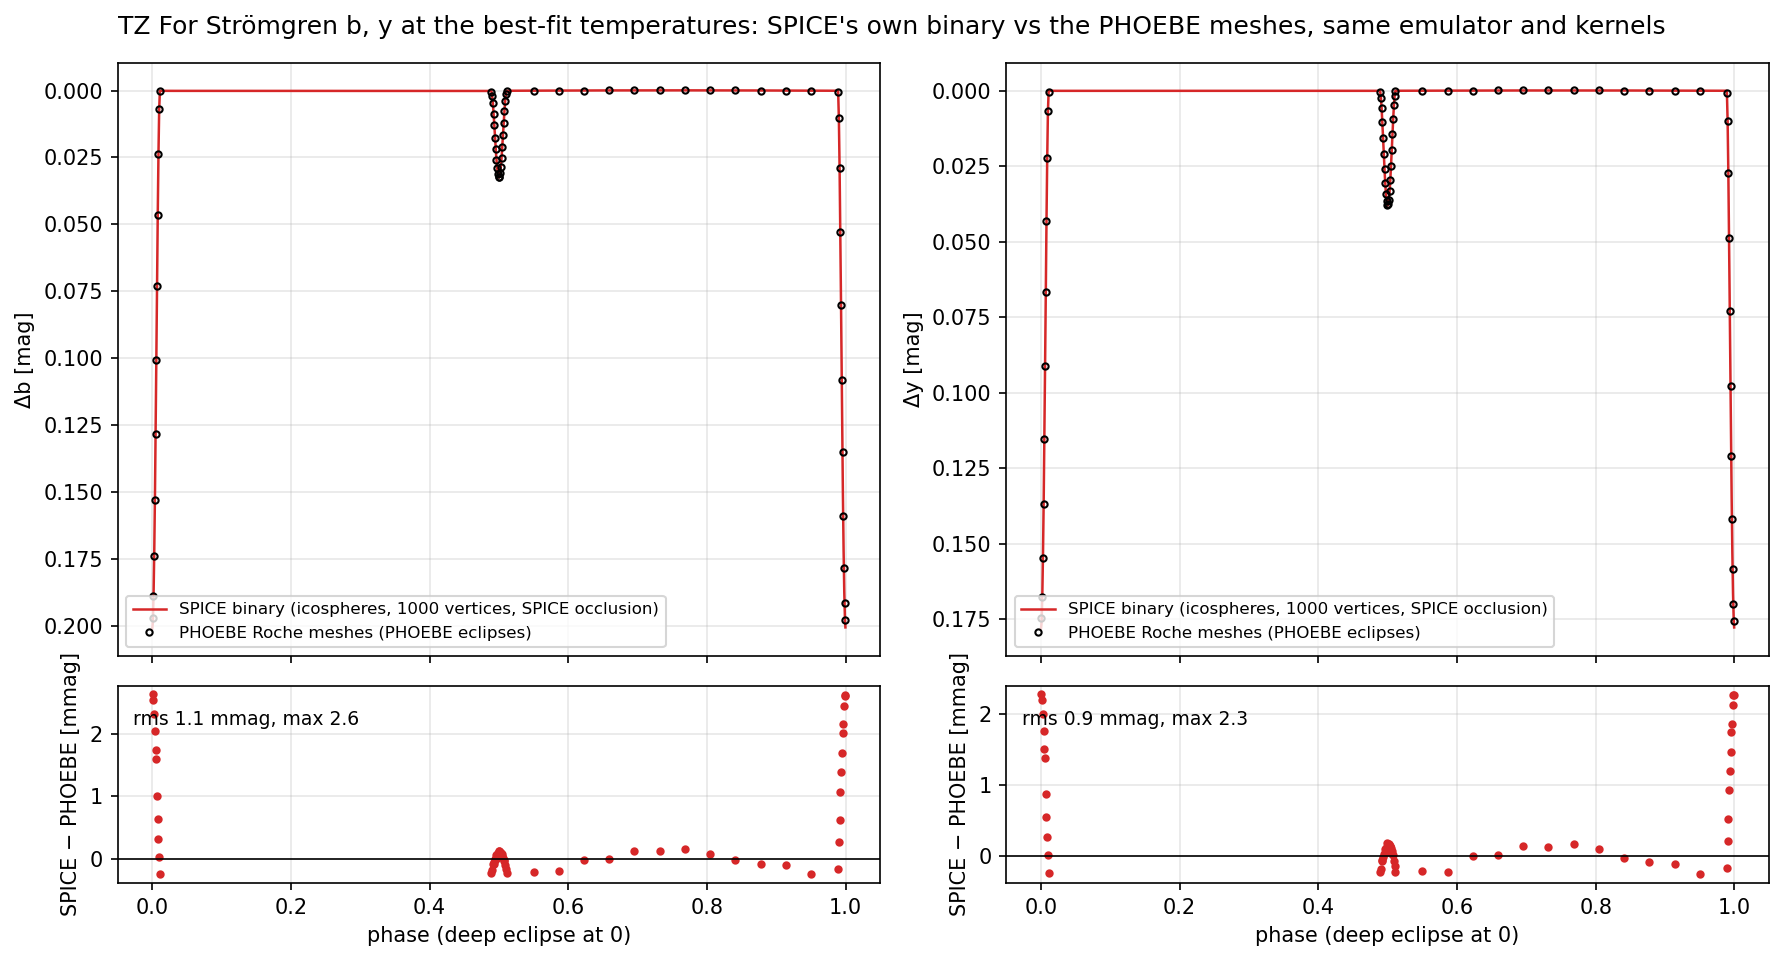

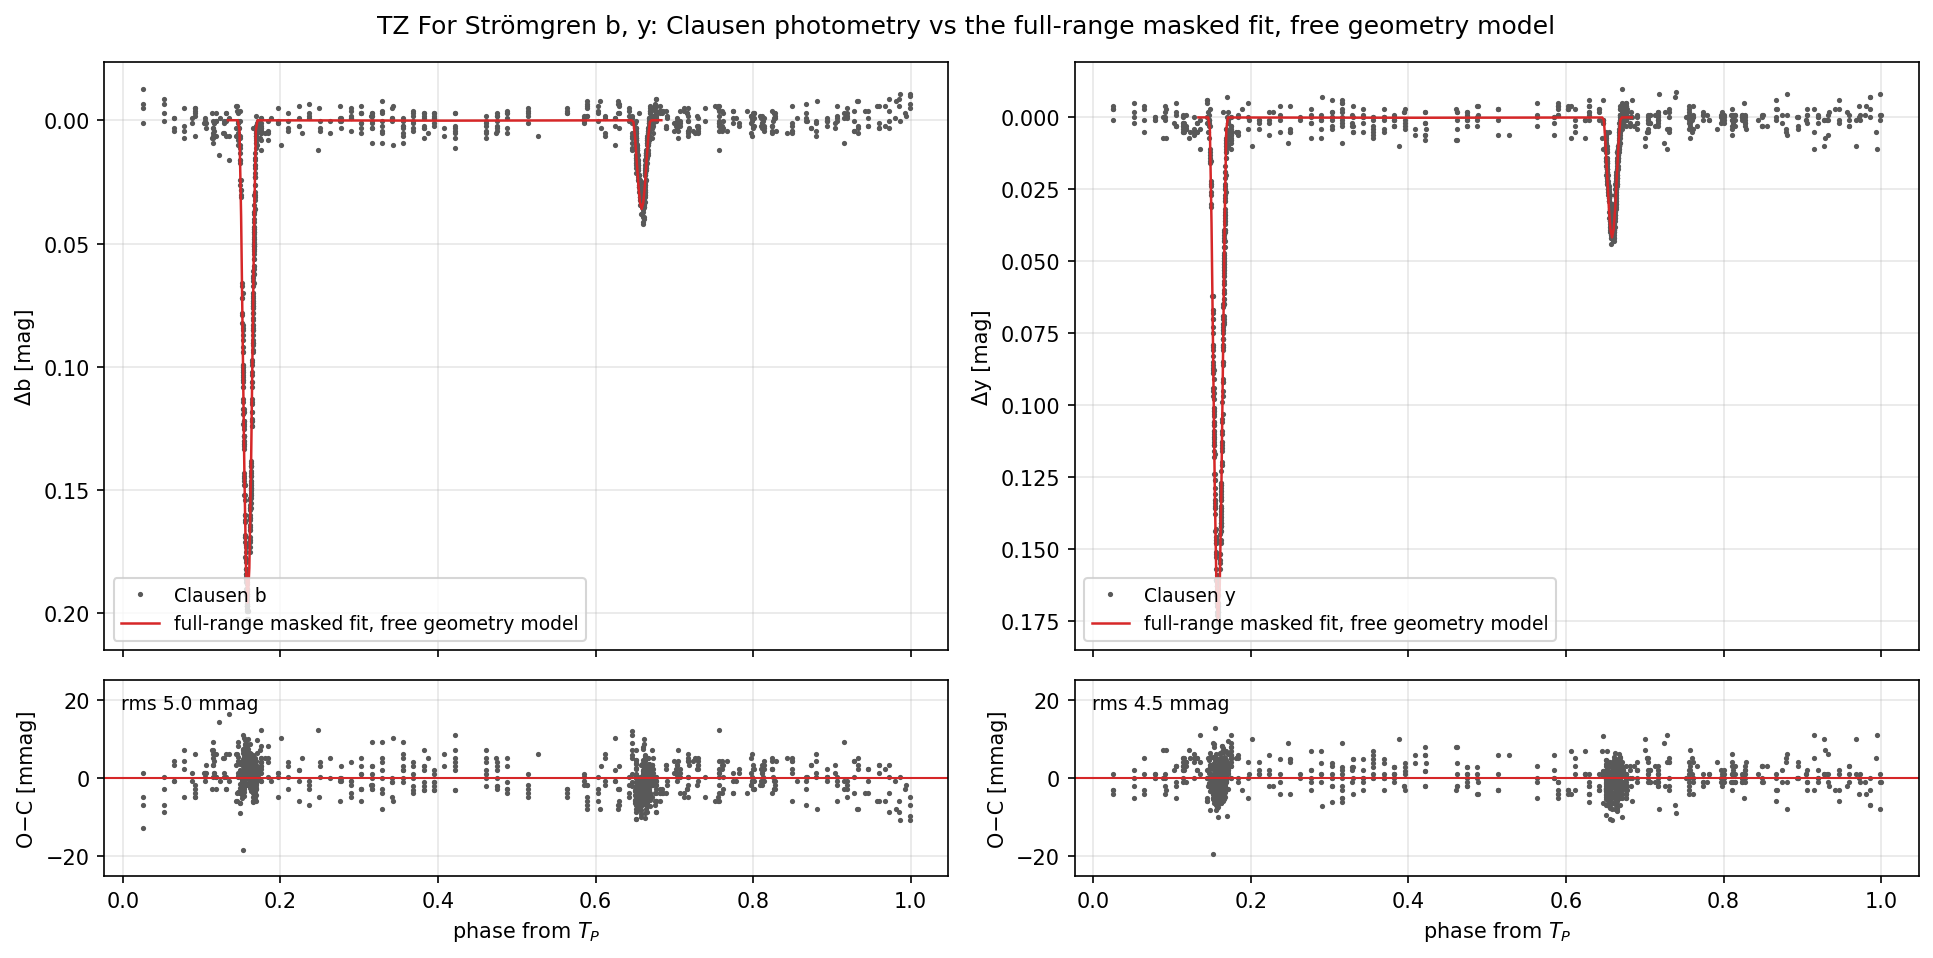

In [11]:
display(Image("../paper_plots/tz_fornacis/tzfor_spice_vs_phoebe_lc.png", width=800))
display(Image("../paper_plots/tz_fornacis/tzfor_lightcurves_fit_fullrange_geo.png", width=800))


## 8. Summary

**Teff2 = 6370 ± 35 (jackknife) ± 50 (treatment) K at the literature geometry, 6240 ± 60 ± 35 K with the geometry free;
Teff1 = 4885 ± 15 ± 20 K; [Fe/H] = −0.22 ± 0.02 ± 0.05** (sections 7.3-7.5), against Andersen's 6650 ± 100 K for the secondary.

* Every route agrees on Teff2 ≈ 6200-6420 K: ck2004 (6406), PHOENIX (6415), MARCS/aemu
  photometry, Mg b spectroscopy alone (6427), the 12-window joint fit (6348-6416), the
  full-range joint fit (6321-6396) and the free-geometry joint fit (6211-6275).
* The secondary's light ratio is 12 % below the literature temperatures' -- that is
  the whole "over-luminous secondary". Freeing R₁, R₂ and i (section 7.5) makes the same
  point geometrically: the line depths push R₂/R₁ from 0.476 to 0.503 ± 0.006 at fixed
  R₁ + R₂, and Teff2 down another 100 K.
* Photometry, in any code, only fixes the light ratio (corr = +1.00); the emulator's
  line synthesis is what breaks the degeneracy. PHOEBE's own emcee sampler drifts
  along the ridge with no interior maximum.
* The residual floor is the emulator's line list for a 4900 K giant: a line-strength
  map derived on half the epochs takes the other half to χ²/N = 1.5 (0.8-1.2 % rms) and
  shifts the solution by −25 / −75 K and −0.1 dex relative to the masked fit; that shift
  is the dominant systematic. Rotation, macroturbulence, gravity darkening and numerical
  precision each move the answer by ≤ 5 K.
* Statistical widths (NUTS) are a kelvin; the quoted errors are jackknife and
  treatment spreads. Remaining tension between photometry and spectroscopy along the
  valley: 55 K (1.5 σ) at fixed geometry, absorbed into R₂ when the geometry is free.
